## 0. Title + abstract                              [narrative]
     What question, why it matters, one-line result

## 1. The well-mixed assumption & why it breaks     [narrative]
     Phase 1 assumes uniform T; cite Miller & Block on gradients

## 2. The physics                                   [narrative]
     heat equation, method of lines, BCs, source term
     the convection paradox + effective diffusivity (cite Bogard)

## 3. Parameters & provenance                       [analysis-light]
     show params table, each value → its paper

## 4. Stage 1 — verifying the boundary conditions   [analysis]
     run_diffusion_test, plot relaxation
     READ: relaxes to T_coolant, Neumann visible as vertical top

## 5. Stage 2 — the fermentation gradient           [analysis]
     run_with_fermentation, 3-panel figure
     READ: 2.3°C gradient, thermal lag

## 6. Grid independence test          ← #7          [analysis] ★
     run N=20, 40, 80, overlay peak gradients
     READ: converges → result is physics not artifact

## 7. Interpolation sensitivity       ← #8          [analysis] ★
     linear vs cubic dSdt_func, compare gradients
     READ: negligible difference → linear justified

## 8. Does the gradient MATTER?       ← #9          [analysis] ★★
     run Phase 1 biology at base T (12°C) vs top T (14.3°C)
     READ: different finish times → gradient changes the wine

## 9. Validation against literature                 [narrative]
     your ±3°C vs Bogard; μ_max vs Coleman

## 10. Known limitations                            [narrative]
     effective α, uniform source, Cp approximation

## 11. Conclusion + link to Phase 3                 [narrative]

In [1]:
#we want to check if the gradient depends on how many layers we use
#if the peak gradient converges as N increases ,the result is physical
import sys
sys.path.insert(0, "..")    # so imports work from notebooks/ directory

import numpy as np
import matplotlib.pyplot as plt
import copy

from src.process.spatial import (
    params,
    run_with_fermentation,
    heat_rhs_with_source,
    get_dSdt_profile,
)
from src.process.simulator import run_simulation, params as ferm_params

import copy

N= 10  →  peak gradient = 3.951 °C
N= 20  →  peak gradient = 3.953 °C
N= 40  →  peak gradient = 3.940 °C
N= 80  →  peak gradient = 3.940 °C


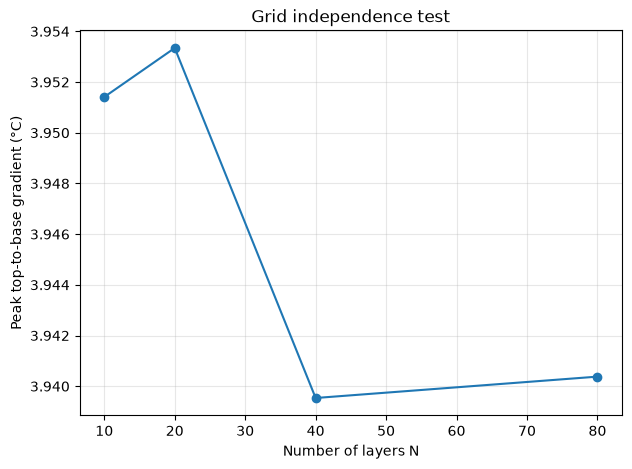

In [4]:


N_values=[10,20,40,80]

peak_gradients=[]

for N_test in N_values:
    p=copy.deepcopy(params)
    p["N"]=N_test
    p["dz"]=p["H"]/(p["N"]-1)


    sol, _ = run_with_fermentation(p, ferm_params) #sol has (N,n_timepoints)->n layers each sampled at n_timepoints times

    #peak gradient 
    top=sol.y[-1,:] #it takes the timepoints
    base=sol.y[0,:]
    grad=top-base
    
    peak_gradients.append(grad.max())

    print(f"N={N_test:3d}  →  peak gradient = {grad.max():.3f} °C")

# plot convergence
plt.figure(figsize=(7, 5))
plt.plot(N_values, peak_gradients, "o-")
plt.xlabel("Number of layers N")
plt.ylabel("Peak top-to-base gradient (°C)")
plt.title("Grid independence test")
plt.grid(True, alpha=0.3)
plt.show()







The peak fermentation-driven gradient converges rapidly:
- **N=40 vs N=80:** differ by little 
- **Interpretation:** grid-independent,not a discretization artifact


linear   →  peak gradient = 3.9395 °C
cubic    →  peak gradient = 3.9402 °C


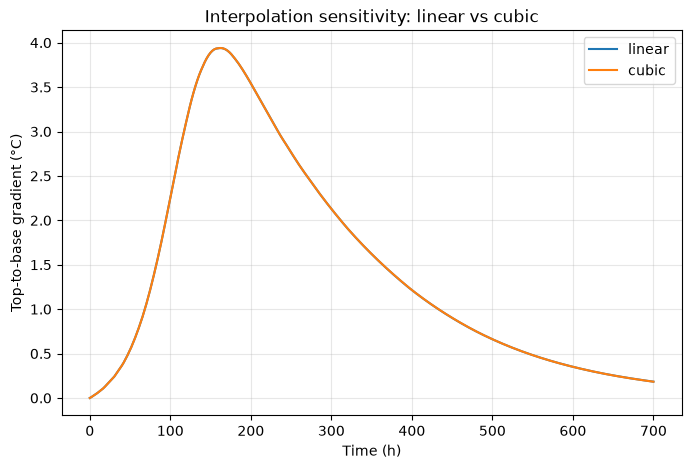

In [ ]:
#Ιnterpolation Sensitivity

#linear vs cubic interpolation of dS/dt change the result?
#linear is fast but introduces small kinks ,cubic is smoother

# Does linear vs cubic interpolation of dS/dt change the result?
# Linear is fast but introduces small kinks; cubic is smoother.
# If the gradient is the same either way, linear is justified.

from scipy.interpolate import interp1d

results = {}
for kind in ["linear", "cubic"]:
    p = copy.deepcopy(params)

    # rebuild the interpolator with this kind
    sol_ferm = run_simulation(ferm_params)
    t_end = sol_ferm.t[-1]
    t_eval = np.linspace(0, t_end, 300)
    dSdt_arr = get_dSdt_profile(t_eval, ferm_params)
    p["dSdt_func"] = interp1d(t_eval, dSdt_arr, kind=kind,
                              bounds_error=False, fill_value=0.0)

    # run with this interpolator 
    N = p["N"]
    T0 = np.full(N, p["T_initial"]); T0[0] = p["T_coolant"]
    from scipy.integrate import solve_ivp
    sol = solve_ivp(heat_rhs_with_source, (0, t_end), T0,
                    args=(p,), method="BDF",
                    t_eval=t_eval, dense_output=True)

    grad = (sol.y[-1, :] - sol.y[0, :])#sol.y is the results ,sol.t is the time (the independant variable)
    results[kind] = grad
    print(f"{kind:7s}  →  peak gradient = {grad.max():.4f} °C")

# overlay
plt.figure(figsize=(8, 5))
for kind, grad in results.items():
    plt.plot(t_eval, grad, label=kind)
plt.xlabel("Time (h)")
plt.ylabel("Top-to-base gradient (°C)")
plt.title("Interpolation sensitivity: linear vs cubic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()








they overlap so we are good->linear is justified (we use it because its faster)